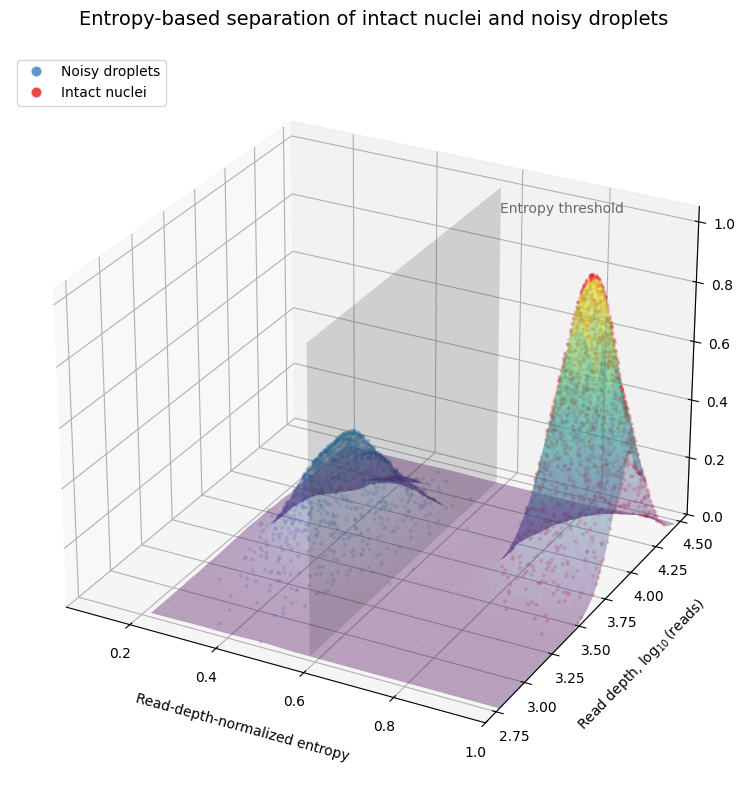

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Reproducibility
rng = np.random.default_rng(7)

# -----------------------------
# Simulate an illustrative dataset
# -----------------------------
n_high = 1800   # droplets containing intact nuclei
n_low = 1200    # noisy/technical droplets

# Read depth per droplet
read_depth_high = rng.lognormal(mean=np.log(8500), sigma=0.40, size=n_high)
read_depth_low  = rng.lognormal(mean=np.log(4500), sigma=0.55, size=n_low)

# Entropy normalized by read depth:
# intact nuclei: higher and more structured entropy
# noisy droplets: lower entropy
entropy_high = (
    0.78
    + 0.035 * np.log10(read_depth_high)
    + rng.normal(0, 0.045, n_high)
)

entropy_low = (
    0.35
    + 0.020 * np.log10(read_depth_low)
    + rng.normal(0, 0.060, n_low)
)

# Combine and constrain values to a valid illustrative range
entropy = np.clip(
    np.concatenate([entropy_low, entropy_high]),
    0.05,
    1.00
)

read_depth = np.concatenate([read_depth_low, read_depth_high])
labels = np.array(
    ["Noisy droplets"] * n_low + ["Intact nuclei"] * n_high
)

# Log-transform read depth for visualization
log_read_depth = np.log10(read_depth)

# -----------------------------
# Estimate local 2D density
# -----------------------------
xy = np.vstack([entropy, log_read_depth])
kde = gaussian_kde(xy, bw_method=0.18)
density = kde(xy)

# Normalize density for convenient plotting
density = density / density.max()

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot low-entropy noisy droplets
low_mask = labels == "Noisy droplets"
high_mask = labels == "Intact nuclei"

ax.scatter(
    entropy[low_mask],
    log_read_depth[low_mask],
    density[low_mask],
    s=8,
    alpha=0.20,
    color="#377eb8",
    edgecolors="none",
    label="Noisy droplets"
)

# Plot high-entropy intact nuclei
ax.scatter(
    entropy[high_mask],
    log_read_depth[high_mask],
    density[high_mask],
    s=8,
    alpha=0.20,
    color="#e41a1c",
    edgecolors="none",
    label="Intact nuclei"
)

# -----------------------------
# Add density surface
# -----------------------------
x_grid = np.linspace(entropy.min(), entropy.max(), 80)
y_grid = np.linspace(log_read_depth.min(), log_read_depth.max(), 80)
X, Y = np.meshgrid(x_grid, y_grid)

grid_points = np.vstack([X.ravel(), Y.ravel()])
Z = kde(grid_points).reshape(X.shape)
Z = Z / Z.max()

ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    alpha=0.35,
    linewidth=0,
    antialiased=True
)

# -----------------------------
# Illustrative entropy threshold
# -----------------------------
entropy_threshold = 0.58
y_plane = np.linspace(log_read_depth.min(), log_read_depth.max(), 20)
z_plane = np.linspace(0, 1.02, 20)
Y_plane, Z_plane = np.meshgrid(y_plane, z_plane)
X_plane = np.full_like(Y_plane, entropy_threshold)

ax.plot_surface(
    X_plane,
    Y_plane,
    Z_plane,
    color="gray",
    alpha=0.18,
    linewidth=0
)

# Threshold label
ax.text(
    entropy_threshold + 0.01,
    log_read_depth.max() - 0.05,
    0.95,
    "Entropy threshold",
    color="dimgray",
    fontsize=10
)

# -----------------------------
# Axis labels and formatting
# -----------------------------
ax.set_xlabel("Read-depth-normalized entropy", labelpad=12)
ax.set_ylabel(r"Read depth, $\log_{10}$(reads)", labelpad=12)
ax.set_zlabel("Droplet density", labelpad=12)

ax.set_title(
    "Entropy-based separation of intact nuclei and noisy droplets",
    pad=20,
    fontsize=14
)

ax.set_xlim(0.05, 1.00)
ax.set_zlim(0, 1.05)
ax.view_init(elev=27, azim=-62)

# Custom legend
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Noisy droplets",
        markerfacecolor="#377eb8",
        markersize=8,
        alpha=0.8
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Intact nuclei",
        markerfacecolor="#e41a1c",
        markersize=8,
        alpha=0.8
    ),
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()


Estimated inflection rank: 3000.0
Estimated entropy threshold: 0.205
Toy-data classification accuracy: 0.600


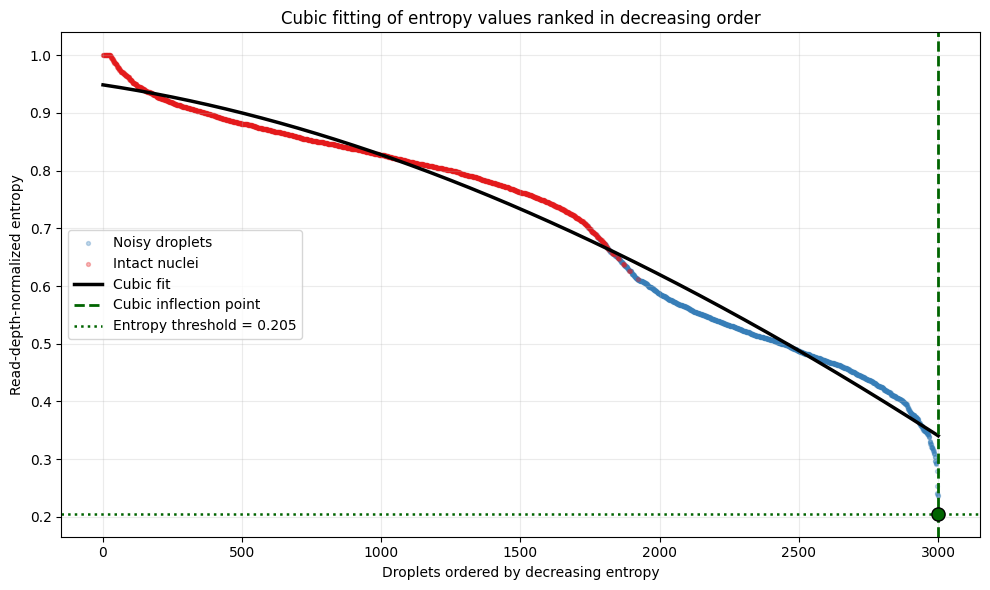

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(7)

# ----------------------------------------------------
# Generate overlapping toy populations
# ----------------------------------------------------
n_high = 1800
n_low = 1200

read_depth_high = rng.lognormal(
    mean=np.log(8500),
    sigma=0.45,
    size=n_high
)

read_depth_low = rng.lognormal(
    mean=np.log(4500),
    sigma=0.60,
    size=n_low
)

# Intact nuclei: higher entropy
entropy_high = (
    0.72
    + 0.030 * np.log10(read_depth_high)
    + rng.normal(0, 0.075, n_high)
)

# Noisy droplets: lower entropy, with overlap
entropy_low = (
    0.43
    + 0.020 * np.log10(read_depth_low)
    + rng.normal(0, 0.085, n_low)
)

entropy = np.clip(
    np.concatenate([entropy_low, entropy_high]),
    0.05,
    1.00
)

read_depth = np.concatenate([
    read_depth_low,
    read_depth_high
])

true_labels = np.array(
    ["Noisy droplets"] * n_low
    + ["Intact nuclei"] * n_high
)

# ----------------------------------------------------
# Rank droplets by decreasing entropy
# ----------------------------------------------------
sort_idx = np.argsort(-entropy)

entropy_sorted = entropy[sort_idx]
read_depth_sorted = read_depth[sort_idx]
true_labels_sorted = true_labels[sort_idx]

rank = np.arange(1, len(entropy_sorted) + 1)

# Scale rank for numerical stability
rank_scaled = (rank - rank.mean()) / rank.std()

# ----------------------------------------------------
# Fit cubic curve to decreasing entropy ranks
# ----------------------------------------------------
cubic_coefficients = np.polyfit(
    rank_scaled,
    entropy_sorted,
    deg=3
)

cubic_model = np.poly1d(cubic_coefficients)
entropy_fitted = cubic_model(rank_scaled)

# ----------------------------------------------------
# Calculate cubic inflection point
# ----------------------------------------------------
a, b, c, d = cubic_coefficients

if np.isclose(a, 0):
    raise ValueError("The fitted polynomial is not sufficiently cubic.")

# For f(x) = ax^3 + bx^2 + cx + d:
# f''(x) = 6ax + 2b
rank_scaled_inflection = -b / (3 * a)

# Convert scaled rank back to the original rank
rank_inflection = (
    rank_scaled_inflection * rank.std()
    + rank.mean()
)

# Keep the inflection point within the observed range
rank_inflection = np.clip(
    rank_inflection,
    rank.min(),
    rank.max()
)

# Obtain entropy at the inflection point
entropy_threshold = np.interp(
    rank_inflection,
    rank,
    entropy_sorted
)

# ----------------------------------------------------
# Classification using the entropy threshold
# ----------------------------------------------------
predicted_labels = np.where(
    entropy >= entropy_threshold,
    "Intact nuclei",
    "Noisy droplets"
)

accuracy = np.mean(predicted_labels == true_labels)

print(f"Estimated inflection rank: {rank_inflection:.1f}")
print(f"Estimated entropy threshold: {entropy_threshold:.3f}")
print(f"Toy-data classification accuracy: {accuracy:.3f}")

# ----------------------------------------------------
# Plot
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

noisy_mask = true_labels_sorted == "Noisy droplets"
intact_mask = true_labels_sorted == "Intact nuclei"

ax.scatter(
    rank[noisy_mask],
    entropy_sorted[noisy_mask],
    s=8,
    alpha=0.30,
    color="#377eb8",
    label="Noisy droplets"
)

ax.scatter(
    rank[intact_mask],
    entropy_sorted[intact_mask],
    s=8,
    alpha=0.30,
    color="#e41a1c",
    label="Intact nuclei"
)

# Cubic fit
ax.plot(
    rank,
    entropy_fitted,
    color="black",
    linewidth=2.5,
    label="Cubic fit"
)

# Inflection-point rank
ax.axvline(
    rank_inflection,
    color="darkgreen",
    linestyle="--",
    linewidth=2,
    label="Cubic inflection point"
)

# Entropy threshold
ax.axhline(
    entropy_threshold,
    color="darkgreen",
    linestyle=":",
    linewidth=1.8,
    label=f"Entropy threshold = {entropy_threshold:.3f}"
)

# Mark inflection point
ax.scatter(
    rank_inflection,
    entropy_threshold,
    color="darkgreen",
    edgecolor="black",
    s=90,
    zorder=5
)

ax.set_xlabel("Droplets ordered by decreasing entropy")
ax.set_ylabel("Read-depth-normalized entropy")
ax.set_title(
    "Cubic fitting of entropy values ranked in decreasing order"
)

ax.grid(alpha=0.25)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()


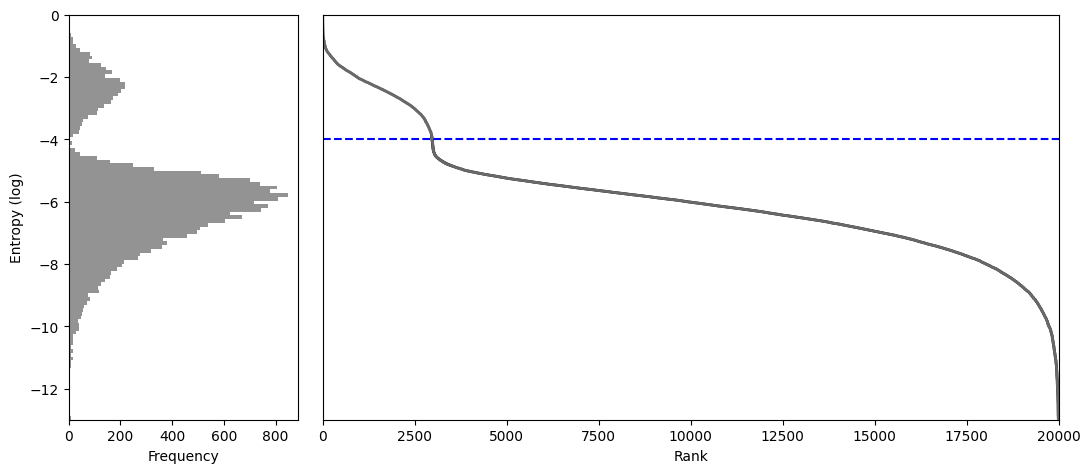

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(12)

# ----------------------------------------------------
# Simulate exactly two populations
# ----------------------------------------------------
n_intact = 3_000
n_artifacts = 17_000

# Population 1: intact nuclei
# Mostly concentrated around intermediate entropy values,
# with a small upper tail approaching zero.
entropy_intact = (
    -2.1
    + rng.normal(0, 0.65, n_intact)
    - rng.exponential(scale=0.25, size=n_intact)
)

# Population 2: noisy droplets / technical artifacts
# Lower entropy and broader distribution.
entropy_artifacts = (
    -4.8
    - rng.gamma(shape=2.0, scale=0.85, size=n_artifacts)
    + rng.normal(0, 0.30, n_artifacts)
)

# Combine the two populations
entropy = np.concatenate([
    entropy_intact,
    entropy_artifacts
])

labels = np.concatenate([
    np.repeat("Intact nuclei", n_intact),
    np.repeat("Noisy droplets", n_artifacts)
])

# Restrict values to the displayed entropy range
entropy = np.clip(entropy, -13, 0)

# ----------------------------------------------------
# Rank droplets by decreasing entropy
# ----------------------------------------------------
sort_idx = np.argsort(-entropy)

entropy_sorted = entropy[sort_idx]
labels_sorted = labels[sort_idx]

rank = np.arange(1, len(entropy_sorted) + 1)

# ----------------------------------------------------
# Illustrative entropy threshold
# ----------------------------------------------------
entropy_threshold = -4.0

# ----------------------------------------------------
# Plot
# ----------------------------------------------------
fig, (ax_hist, ax_rank) = plt.subplots(
    1,
    2,
    figsize=(11, 5),
    gridspec_kw={"width_ratios": [1.0, 3.2]},
    sharey=True
)

# ----------------------------------------------------
# Left panel: entropy distribution
# ----------------------------------------------------
bins = np.linspace(-13, 0, 110)

ax_hist.hist(
    entropy,
    bins=bins,
    orientation="horizontal",
    color="gray",
    alpha=0.85,
    edgecolor="none"
)

ax_hist.set_xlabel("Frequency")
ax_hist.set_ylabel("Entropy (log)")
ax_hist.set_xlim(left=0)

# ----------------------------------------------------
# Right panel: ranked entropy values
# ----------------------------------------------------
# Plot the two populations using their true simulated labels
intact_mask = labels_sorted == "Intact nuclei"
artifact_mask = labels_sorted == "Noisy droplets"

ax_rank.plot(
    rank[intact_mask],
    entropy_sorted[intact_mask],
    color="dimgray",
    linewidth=2.0,
    label="Intact nuclei"
)

ax_rank.plot(
    rank[artifact_mask],
    entropy_sorted[artifact_mask],
    color="black",
    linewidth=2.0,
    label="Noisy droplets"
)

# Draw the complete ranked curve on top
ax_rank.plot(
    rank,
    entropy_sorted,
    color="dimgray",
    linewidth=2.0
)

# Entropy threshold
ax_rank.axhline(
    entropy_threshold,
    color="blue",
    linestyle="--",
    linewidth=1.5
)

ax_rank.set_xlabel("Rank")
ax_rank.set_xlim(0, len(rank))
ax_rank.set_ylim(-13, 0)

# Match the reference-style appearance
ax_rank.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

ax_rank.grid(False)

plt.subplots_adjust(
    wspace=0.05,
    left=0.08,
    right=0.98,
    bottom=0.14,
    top=0.95
)

plt.show()


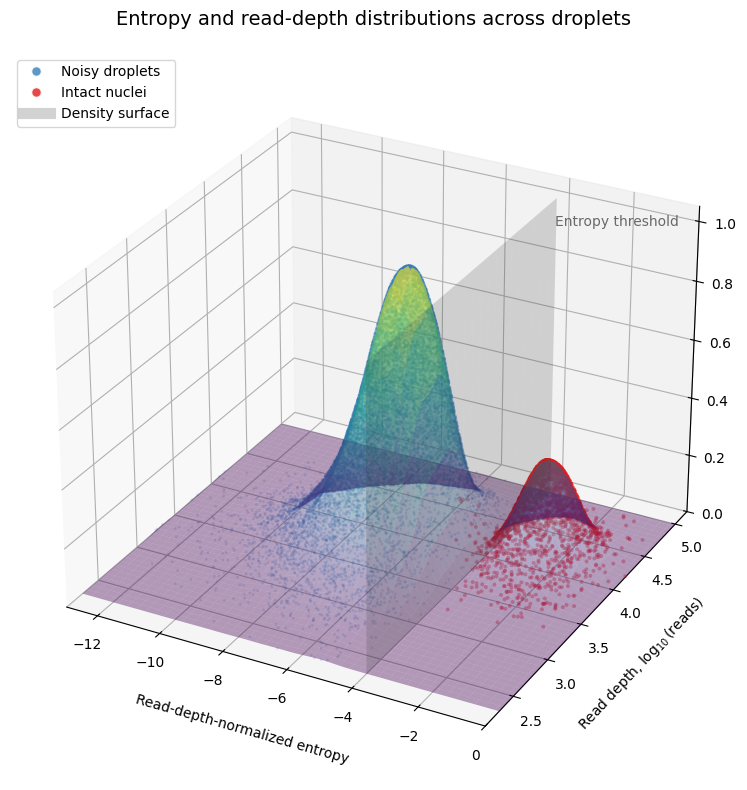

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

# Reproducibility
rng = np.random.default_rng(12)

# ----------------------------------------------------
# Simulate exactly two entropy populations
# ----------------------------------------------------
n_intact = 3_000
n_artifacts = 17_000

# Intact nuclei: higher entropy
entropy_intact = (
    -2.1
    + rng.normal(0, 0.65, n_intact)
    - rng.exponential(scale=0.25, size=n_intact)
)

# Noisy droplets: lower entropy
entropy_artifacts = (
    -4.8
    - rng.gamma(shape=2.0, scale=0.85, size=n_artifacts)
    + rng.normal(0, 0.30, n_artifacts)
)

# Combine entropy values
entropy = np.concatenate([
    entropy_intact,
    entropy_artifacts
])

labels = np.concatenate([
    np.repeat("Intact nuclei", n_intact),
    np.repeat("Noisy droplets", n_artifacts)
])

# Restrict entropy to the plotted range
entropy = np.clip(entropy, -13, 0)

# ----------------------------------------------------
# Generate corresponding read-depth values
# ----------------------------------------------------
# Read depth is simulated independently but with:
# - higher typical depth for intact nuclei
# - lower and more variable depth for noisy droplets
#
# Entropy remains the normalized quality metric, allowing
# comparison across a broad range of read depths.

read_depth_intact = rng.lognormal(
    mean=np.log(12_000),
    sigma=0.55,
    size=n_intact
)

read_depth_artifacts = rng.lognormal(
    mean=np.log(5_000),
    sigma=0.85,
    size=n_artifacts
)

read_depth = np.concatenate([
    read_depth_intact,
    read_depth_artifacts
])

# Avoid extremely small or excessively large values
read_depth = np.clip(read_depth, 200, 100_000)

# Use log10(read depth) for visualization
log_read_depth = np.log10(read_depth)

# ----------------------------------------------------
# Estimate local density in entropy/read-depth space
# ----------------------------------------------------
# Density is estimated in the 2D space defined by:
#   x = entropy
#   y = log10(read depth)
#
# The resulting KDE value is plotted along the z-axis.

xy = np.vstack([
    entropy,
    log_read_depth
])

kde = gaussian_kde(
    xy,
    bw_method=0.18
)

density = kde(xy)

# Normalize density to simplify visualization
density = density / density.max()

# ----------------------------------------------------
# Create a grid for the density surface
# ----------------------------------------------------
entropy_grid = np.linspace(
    entropy.min(),
    entropy.max(),
    90
)

read_depth_grid = np.linspace(
    log_read_depth.min(),
    log_read_depth.max(),
    90
)

X, Y = np.meshgrid(
    entropy_grid,
    read_depth_grid
)

grid_points = np.vstack([
    X.ravel(),
    Y.ravel()
])

Z = kde(grid_points).reshape(X.shape)
Z = Z / Z.max()

# ----------------------------------------------------
# Create the 3D figure
# ----------------------------------------------------
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

intact_mask = labels == "Intact nuclei"
artifact_mask = labels == "Noisy droplets"

# Plot noisy droplets
ax.scatter(
    entropy[artifact_mask],
    log_read_depth[artifact_mask],
    density[artifact_mask],
    s=4,
    alpha=0.18,
    color="#377eb8",
    edgecolors="none"
)

# Plot intact nuclei
ax.scatter(
    entropy[intact_mask],
    log_read_depth[intact_mask],
    density[intact_mask],
    s=8,
    alpha=0.35,
    color="#e41a1c",
    edgecolors="none"
)

# Plot the density surface
ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    alpha=0.38,
    linewidth=0,
    antialiased=True
)

# ----------------------------------------------------
# Add an illustrative entropy-separation plane
# ----------------------------------------------------
entropy_threshold = -4.0

y_plane = np.linspace(
    log_read_depth.min(),
    log_read_depth.max(),
    25
)

z_plane = np.linspace(
    0,
    1.02,
    25
)

Y_plane, Z_plane = np.meshgrid(
    y_plane,
    z_plane
)

X_plane = np.full_like(
    Y_plane,
    entropy_threshold
)

ax.plot_surface(
    X_plane,
    Y_plane,
    Z_plane,
    color="gray",
    alpha=0.18,
    linewidth=0
)

# ----------------------------------------------------
# Axis labels and formatting
# ----------------------------------------------------
ax.set_xlabel(
    "Read-depth-normalized entropy",
    labelpad=12
)

ax.set_ylabel(
    r"Read depth, $\log_{10}$(reads)",
    labelpad=12
)

ax.set_zlabel(
    "Droplet density",
    labelpad=12
)

ax.set_title(
    "Entropy and read-depth distributions across droplets",
    pad=20,
    fontsize=14
)

# Add threshold annotation
ax.text(
    entropy_threshold + 0.15,
    log_read_depth.max() - 0.1,
    0.95,
    "Entropy threshold",
    color="dimgray",
    fontsize=10
)

# Custom legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Noisy droplets",
        markerfacecolor="#377eb8",
        markersize=7,
        alpha=0.8
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Intact nuclei",
        markerfacecolor="#e41a1c",
        markersize=7,
        alpha=0.8
    ),
    Line2D(
        [0],
        [0],
        color="gray",
        linewidth=8,
        alpha=0.35,
        label="Density surface"
    )
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True
)

ax.set_xlim(-13, 0)
ax.set_zlim(0, 1.05)

# Adjust camera angle
ax.view_init(
    elev=28,
    azim=-62
)

plt.tight_layout()
plt.show()


Text(0, 0.5, 'Read-depth-normalized entropy')

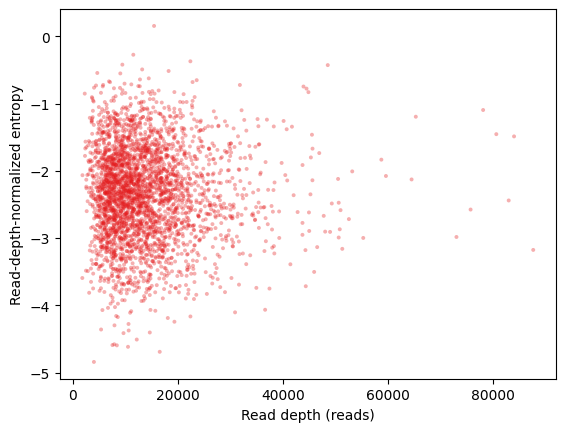

In [23]:
fig, ax = plt.subplots()

ax.scatter(read_depth_intact, entropy_intact, s=8, alpha=0.35, color="#e41a1c", edgecolors="none", label="Intact nuclei")
ax.set_xlabel("Read depth (reads)")
ax.set_ylabel("Read-depth-normalized entropy")